# ionresolver — Test Notebook

Run each cell in order. Every cell prints something so you know whether it worked.

**If a cell fails, stop and read the error — don't run the next one.**

---
## 1. Check the environment

In [1]:
import sys
print("Python:", sys.version.split()[0])

missing = []
for pkg in ["numpy", "pandas", "scipy", "sklearn", "matplotlib", "pyimzml"]:
    try:
        __import__(pkg)
        print(f"  OK      {pkg}")
    except ImportError:
        print(f"  MISSING {pkg}")
        missing.append(pkg)

if missing:
    print("\nInstall with:  pip install " + " ".join(missing))
else:
    print("\nAll packages present.")

Python: 3.10.9
  OK      numpy
  OK      pandas
  OK      scipy
  OK      sklearn
  OK      matplotlib
  OK      pyimzml

All packages present.


---
## 2. Import ionresolver

If this fails with `ModuleNotFoundError`, run `pip install -e .` inside the
ionresolver folder first.

In [2]:
import ionresolver as ir

print("ionresolver version:", ir.__version__)
print("public API symbols :", len(ir.__all__))
print("transformations    :", len(ir.ALL_TRANSFORMATIONS))

ionresolver version: 0.4.0
public API symbols : 44
transformations    : 25


---
## 3. Sanity-check the mass arithmetic

Everything depends on this being exact. Checked against published monoisotopic masses.

In [3]:
import pandas as pd

checks = [
    ("C6H12O6",     180.063388, "glucose"),
    ("H2O",          18.010565, "water"),
    ("C9H8O4",      180.042259, "aspirin"),
    ("C42H82NO8P",  759.577805, "PC(34:1) neutral"),
]

rows = []
for formula, expected, label in checks:
    got = ir.exact_mass(formula)
    rows.append({
        "compound": label,
        "formula": formula,
        "calculated": round(got, 6),
        "expected": expected,
        "ppm_error": round(ir.ppm_error(got, expected), 3),
    })

pd.DataFrame(rows)

,compound,formula,calculated,expected,ppm_error
0,glucose,C6H12O6,180.063388,180.063388,0.001
1,water,H2O,18.010565,18.010565,-0.017
2,aspirin,C9H8O4,180.042259,180.042259,-0.001
3,PC(34:1) neutral,C42H82NO8P,759.577805,759.577805,0.000


PC(34:1) should give **760.5851** as [M+H]+ and **782.5670** as [M+Na]+.

In [4]:
neutral = ir.exact_mass("C42H82NO8P")

for adduct in ir.POSITIVE_ADDUCTS:
    print(f"{adduct.name:<14} m/z {adduct.mz(neutral):10.4f}")

[M+H]+         m/z   760.5851
[M+Na]+        m/z   782.5670
[M+K]+         m/z   798.5410
[M+NH4]+       m/z   777.6116


---
## 4. The biotransformation catalogue

These exact mass shifts are what the algorithm searches for.

In [5]:
tbl = pd.DataFrame(ir.transformation_table())
tbl

,name,category,mass_shift,gains,loses,reversible,note
0,glucuronide cleavage,microbial,-176.032088,-,C6H8O6,False,bacterial beta-glucuronidase; enterohepatic re...
1,sulfate removal,microbial,-79.956815,-,SO3,False,bacterial sulfatases
2,indole formation,microbial,-60.021129,-,C2H4O2,False,tryptophan catabolism by gut flora
3,decarboxylation,phase_i,-43.989829,-,CO2,False,
4,dehydroxylation,microbial,-15.994915,-,O,False,gut bacterial bile acid metabolism
5,dehydrogenation,phase_i,-2.015650,-,H2,True,
6,desaturation,lipid,-2.015650,-,H2,False,one extra double bond
7,deamination,phase_i,-1.031634,O,NH3,False,
8,reduction,phase_i,2.015650,H2,-,True,
9,oxidation to ketone,phase_i,13.979265,O,H2,False,


### Validate against published chemistry

The three Phase II conjugates from *Biomed Pharmacother* 2025;193:118755.

In [6]:
validations = [
    ("benzoate -> hippurate",        "C7H6O2",  "C9H9NO3",    "glycine conjugation"),
    ("p-cresol -> p-cresol sulfate", "C7H8O",   "C7H8O4S",    "sulfation"),
    ("phenylacetate -> PAG",         "C8H8O2",  "C13H16N2O4", "glutamine conjugation"),
]

rows = []
for label, parent, product, tname in validations:
    observed = ir.exact_mass(product) - ir.exact_mass(parent)
    tr = next(t for t in ir.ALL_TRANSFORMATIONS if t.name == tname)
    rows.append({
        "reaction": label,
        "observed_shift": round(observed, 4),
        "catalogue_shift": round(tr.mass_shift, 4),
        "match": abs(observed - tr.mass_shift) < 1e-4,
    })

pd.DataFrame(rows)

,reaction,observed_shift,catalogue_shift,match
0,benzoate -> hippurate,57.0215,57.0215,True
1,p-cresol -> p-cresol sulfate,79.9568,79.9568,True
2,phenylacetate -> PAG,128.0586,128.0586,True


---
## 5. Test annotation on a toy peak list

In [7]:
compounds = pd.DataFrame([
    ("Glucose",       "C6H12O6"),
    ("Phenylalanine", "C9H11NO2"),
    ("Carnitine",     "C7H15NO3"),
    ("LPC(16:0)",     "C24H50NO7P"),
    ("PC(34:1)",      "C42H82NO8P"),
    ("PC(O-34:1)",    "C42H84NO7P"),
], columns=["name", "formula"])

db = ir.CompoundDatabase(compounds, polarity="positive")
print(f"{db.n_compounds} compounds x {len(db.adducts)} adducts = {len(db)} searchable ions")

6 compounds x 4 adducts = 24 searchable ions


In [8]:
peaks = [166.0863, 760.5851, 496.3398, 999.9999]

ann = ir.annotate_peaklist(peaks, db, tol_ppm=10.0)
ann[["mz_observed", "name", "adduct", "ppm", "level", "n_candidates"]]

,mz_observed,name,adduct,ppm,level,n_candidates
0,166.0863,Phenylalanine,[M+H]+,0.27,L4,1
1,760.5851,PC(34:1),[M+H]+,0.02,L4,1
2,496.3398,LPC(16:0),[M+H]+,0.07,L4,1
3,999.9999,UNKNOWN,?,NaN,L4,0


**Look at `n_candidates`.** Where it's greater than 1, accurate mass alone
cannot decide — that is the isomer/isobar problem made visible.

In [9]:
plain   = ir.annotate_mz(760.5851, db, tol_ppm=10, has_msms=False)[0]
withms  = ir.annotate_mz(760.5851, db, tol_ppm=10, has_msms=True)[0]
withstd = ir.annotate_mz(760.5851, db, tol_ppm=10, has_msms=True, has_standard=True)[0]

print(f"mass only               -> {plain.level}")
print(f"mass + MS/MS            -> {withms.level}")
print(f"mass + MS/MS + standard -> {withstd.level}")

mass only               -> L4
mass + MS/MS            -> L2
mass + MS/MS + standard -> L1


---
## 6. Test the algorithm on synthetic data

Two planted cases:
1. parent + sulfate conjugate that **do** colocalise — should be found
2. correct mass difference, **different** locations — should be rejected

In [10]:
import numpy as np

rng = np.random.default_rng(0)
n_px = 400

sulfation = next(t for t in ir.ALL_TRANSFORMATIONS if t.name == "sulfation")
print(f"sulfation mass shift: {sulfation.mass_shift:.4f}")

shared = np.zeros(n_px)
shared[:150] = rng.uniform(5, 10, 150)

parent_mz = 200.0
child_mz  = parent_mz + sulfation.mass_shift

mzs_toy = np.array([parent_mz, child_mz])
X_toy   = np.column_stack([shared, shared * 0.6 + 0.1])

found = ir.propagate(X_toy, mzs_toy, {0: "TestParent"}, tol_ppm=5.0, coloc_min=0.5)
print(f"\nCASE 1 (colocalised) -> {len(found)} hit(s)")
if len(found):
    print(found[["mz_unknown", "proposed_name", "transformation", "coloc"]].to_string(index=False))

sulfation mass shift: 79.9568

CASE 1 (colocalised) -> 1 hit(s)
 mz_unknown          proposed_name transformation  coloc
  279.95681 TestParent + sulfation      sulfation    1.0


In [11]:
a = np.concatenate([np.ones(200) * 10, np.zeros(200)])
b = np.concatenate([np.zeros(200), np.ones(200) * 10])

mzs2 = np.array([200.0, 200.0 + sulfation.mass_shift])
X2   = np.column_stack([a, b])

rejected = ir.propagate(X2, mzs2, {0: "TestParent"}, tol_ppm=5.0, coloc_min=0.6)
print(f"CASE 2 (not colocalised) -> {len(rejected)} hit(s)   <- should be 0")
print(f"colocalisation between them: {ir.cosine_coloc(a, b):.3f}")

CASE 2 (not colocalised) -> 0 hit(s)   <- should be 0
colocalisation between them: 0.000


Case 2 is the point. The mass difference is *exactly* right, but the spatial
constraint rejects it. Mass alone would have called it a hit.

---
## 7. Load real data

**Edit the path below.** This cell can take a minute or two.

In [12]:
from pyimzml.ImzMLParser import ImzMLParser
from scipy import sparse

IMZML = "/Users/AMARMAC/projects/msi-data/Untreated_3_434.imzML"   # <-- EDIT IF NEEDED

p = ImzMLParser(IMZML)
n = len(p.coordinates)
coords = np.array(p.coordinates)[:, :2] - 1

print(f"pixels : {n}")
print(f"grid   : x {coords[:,0].min()}-{coords[:,0].max()}, y {coords[:,1].min()}-{coords[:,1].max()}")

mz0, int0 = p.getspectrum(0)
mz1, _    = p.getspectrum(1)
is_continuous = len(mz1) == len(mz0) and np.allclose(mz1, mz0)

print(f"peaks in pixel 0: {len(mz0)}")
print(f"m/z range       : {mz0.min():.2f} - {mz0.max():.2f}")
print(f"format          : {'CONTINUOUS' if is_continuous else 'PROCESSED (needs binning)'}")

/Users/AMARMAC/anaconda3/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:80: UserWarning: Unrecognized accession in <cvParam>: MS:xxx (name: "pyimzml").
  warn('Unrecognized accession in <cvParam>: %s (name: "%s").' % (accession, raw_name))
/Users/AMARMAC/anaconda3/lib/python3.10/site-packages/pyimzml/metadata.py:214: UserWarning: ReferenceableParamGroup "spectrum" not found
  warn('ReferenceableParamGroup "%s" not found' % ref)


pixels : 4850
grid   : x -1-70, y -1-68
peaks in pixel 0: 1022
m/z range       : 151.34 - 2637.47
format          : PROCESSED (needs binning)


### Bin onto a common m/z axis

**Why sparse:** at 5 ppm over 150-1000 Da you get ~380,000 bins. Dense storage
for 5,000 pixels is ~7 GB and will kill the kernel. If this cell runs out of
memory, raise `MIN_OCCUPANCY` to 0.20.

In [13]:
MZ_LO, MZ_HI, PPM = 150.0, 1000.0, 5.0
MIN_OCCUPANCY = 0.10

edges = [MZ_LO]
while edges[-1] < MZ_HI:
    edges.append(edges[-1] * (1 + PPM * 1e-6))
edges = np.array(edges)
centers = (edges[:-1] + edges[1:]) / 2
print(f"{len(centers):,} bins at {PPM} ppm")

rows_, cols_, vals_ = [], [], []
for i in range(n):
    mz, it = p.getspectrum(i)
    k = (mz >= MZ_LO) & (mz < MZ_HI) & (it > 0)
    if k.sum() == 0:
        continue
    idx = np.searchsorted(edges, mz[k]) - 1
    rows_.append(np.full(k.sum(), i)); cols_.append(idx); vals_.append(it[k])

Xsp = sparse.csr_matrix(
    (np.concatenate(vals_), (np.concatenate(rows_), np.concatenate(cols_))),
    shape=(n, len(centers)), dtype=np.float32)
print(f"sparse: nnz={Xsp.nnz:,}  density={Xsp.nnz/np.prod(Xsp.shape)*100:.4f}%")

occ = np.asarray((Xsp > 0).sum(0)).ravel() / n
keep = np.where(occ >= MIN_OCCUPANCY)[0]
X = np.asarray(Xsp[:, keep].todense())
mzs = centers[keep]

print(f"after occupancy >= {MIN_OCCUPANCY}: {X.shape[1]} features")

379,425 bins at 5.0 ppm
sparse: nnz=4,380,106  density=0.2380%
after occupancy >= 0.1: 1866 features


### Merge peaks split across adjacent bins

Binning at 5 ppm routinely splits one peak across two neighbouring bins. Both
survive the occupancy filter, both get propagated, and the same relationship is
reported twice under different names. Merge them first.

In [14]:
before = len(mzs)
mzs, X, merge_map = ir.merge_split_features(mzs, X, tol_ppm=6.0)
merged_groups = sum(1 for v in merge_map.values() if len(v) > 1)

print(f"features before merge : {before}")
print(f"features after merge  : {len(mzs)}")
print(f"groups merged         : {merged_groups}")

features before merge : 1866
features after merge  : 1433
groups merged         : 387


### Mask to tissue and normalise

In [15]:
on = ir.on_tissue_mask(X, percentile=30)
Xn = ir.tic_normalize(X[on])

print(f"on-tissue pixels: {on.sum()} / {len(X)}")
print(f"matrix for analysis: {Xn.shape}")

on-tissue pixels: 3395 / 4850
matrix for analysis: (3395, 1433)


### Look at the tissue

The TIC image should show a tissue outline. If it looks like noise, something
is wrong with the mask or the m/z range.

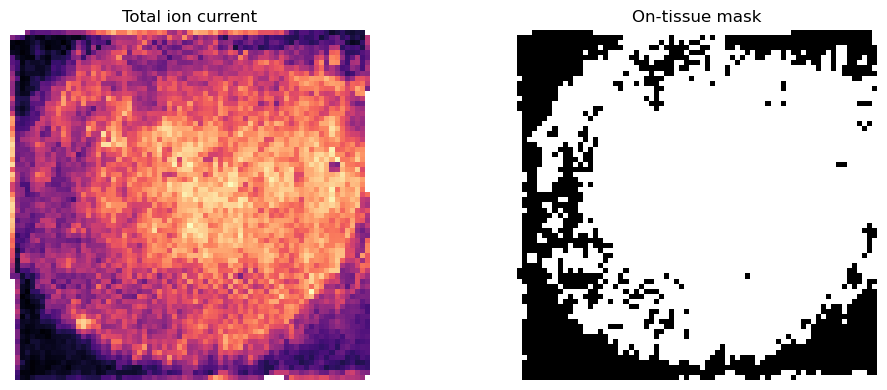

In [16]:
import matplotlib.pyplot as plt

H = coords[:,1].max() + 1
W = coords[:,0].max() + 1

tic_img = np.full((H, W), np.nan)
tic_img[coords[:,1], coords[:,0]] = X.sum(1)

mask_img = np.full((H, W), np.nan)
mask_img[coords[:,1], coords[:,0]] = on.astype(float)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(tic_img, cmap="magma"); ax[0].set_title("Total ion current"); ax[0].axis("off")
ax[1].imshow(mask_img, cmap="Greys_r"); ax[1].set_title("On-tissue mask"); ax[1].axis("off")
plt.tight_layout(); plt.show()

---
## 8. Annotate the real data

In [17]:
seed_compounds = pd.DataFrame([
    ("Choline","C5H13NO"), ("Betaine","C5H11NO2"), ("Carnitine","C7H15NO3"),
    ("Creatine","C4H9N3O2"), ("Phenylalanine","C9H11NO2"), ("Tryptophan","C11H12N2O2"),
    ("Adenine","C5H5N5"), ("Adenosine","C10H13N5O4"), ("Glutathione","C10H17N3O6S"),
    ("Spermidine","C7H19N3"), ("Glucose","C6H12O6"), ("Palmitoylcarnitine","C23H45NO4"),
    ("LPC(16:0)","C24H50NO7P"), ("LPC(18:0)","C26H54NO7P"), ("LPC(18:1)","C26H52NO7P"),
    ("SM(d18:1/16:0)","C39H79N2O6P"), ("PC(32:0)","C40H80NO8P"), ("PC(34:1)","C42H82NO8P"),
    ("PC(36:2)","C44H86NO8P"), ("PC(38:4)","C46H86NO8P"),
], columns=["name","formula"])

db_real = ir.CompoundDatabase(seed_compounds, polarity="positive")
ann_real = ir.annotate_peaklist(mzs, db_real, tol_ppm=8.0)

print("CONFIDENCE DISTRIBUTION")
print(ir.confidence_summary(ann_real).to_string(index=False))

CONFIDENCE DISTRIBUTION
level    n  percent
   L4 1433    100.0


In [18]:
seeds   = ir.seeds_from_annotations(ann_real, mzs, min_level="L4", tol_ppm=8.0)
adducts = ir.seed_adducts_from_annotations(ann_real, mzs, min_level="L4", tol_ppm=8.0)

print(f"seeded features : {len(seeds)}")
print(f"unknown features: {len(mzs) - len(seeds)}")
print(f"annotated       : {len(seeds)/len(mzs)*100:.1f}%")
print()
print("adducts represented among seeds:")
print(pd.Series(list(adducts.values())).value_counts().to_string())

seeded features : 30
unknown features: 1403
annotated       : 2.1%

adducts represented among seeds:
[M+K]+     11
[M+H]+     10
[M+Na]+     9


That percentage is the problem statement.

---
## 9. Run the propagation

This is the algorithm. May take a few minutes.

In [19]:
# This dataset is a 3D CELL CULTURE - no gut flora, so microbial chemistry
# is impossible here however well the mass and colocalisation agree.
prop = ir.propagate(
    Xn, mzs, seeds,
    seed_adducts=adducts,            # record which parent ion the arithmetic used
    tol_ppm=8.0,
    coloc_min=0.60,
    sample_context="cell_culture",   # drop microbial transformations
)

print(f"{len(prop)} unknowns given a putative identity\n")
prop[["mz_unknown","parent_name","parent_adduct","transformation","ppm","coloc"]].head(20)

39 unknowns given a putative identity



,mz_unknown,parent_name,parent_adduct,transformation,ppm,coloc
0,854.60658,PC(36:2),[M+K]+,chain extension (C2H4),-1.52,0.983
1,494.32414,LPC(16:0),[M+H]+,dehydrogenation,-0.38,0.982
2,532.27998,LPC(16:0),[M+K]+,dehydrogenation,-0.32,0.976
3,428.37337,Palmitoylcarnitine,[M+H]+,chain extension (C2H4),-0.92,0.974
4,832.58633,PC(38:4),[M+Na]+,dehydrogenation,-0.49,0.967
5,398.32584,Palmitoylcarnitine,[M+H]+,dehydrogenation,-2.46,0.963
6,796.52740,PC(34:1),[M+K]+,dehydrogenation,0.26,0.958
7,784.58587,PC(34:1),[M+Na]+,reduction,1.44,0.956
8,824.55886,PC(36:2),[M+K]+,reverse reduction,-2.51,0.952
9,808.58431,PC(36:2),[M+Na]+,dehydrogenation,-2.73,0.951


In [20]:
if len(prop):
    display(prop.groupby("category").size().reset_index(name="n"))
    display(prop.groupby("transformation").size().sort_values(ascending=False).head(10).reset_index(name="n"))

,category,n
0,lipid,14
1,phase_i,25


,transformation,n
0,chain extension (C2H4),6
1,dehydrogenation,6
2,desaturation,6
3,reverse dehydrogenation,6
4,reverse reduction,6
5,reduction,4
6,acetyl-CoA unit,1
7,epoxidation,1
8,hydration,1
9,hydroxylation,1


### 9a. What each filter removes

`propagate()` applies three filters by default. This shows what each one costs
you — and, more importantly, what it saves you from.

In [21]:
configs = [
    ("mass + coloc only",       dict(check_plausibility=False, dedupe_by_mass=False, exclude_artefacts=False)),
    ("+ collapse duplicates",   dict(check_plausibility=False, dedupe_by_mass=True,  exclude_artefacts=False)),
    ("+ chemical plausibility", dict(check_plausibility=True,  dedupe_by_mass=True,  exclude_artefacts=False)),
    ("+ in-source artefacts",   dict(check_plausibility=True,  dedupe_by_mass=True,  exclude_artefacts=True)),
    ("+ cell-culture context",  dict(check_plausibility=True,  dedupe_by_mass=True,  exclude_artefacts=True,
                                     sample_context="cell_culture")),
]

prev = None
for label, kw in configs:
    r = ir.propagate(Xn, mzs, seeds, tol_ppm=8.0, coloc_min=0.60, **kw)
    delta = "" if prev is None else f"   ({prev - len(r):+d})"
    print(f"{label:<26}: {len(r):>4} hits{delta}")
    prev = len(r)

print()
print("Features were also merged before this ran, which removes split-bin duplicates.")

mass + coloc only         :  101 hits
+ collapse duplicates     :  101 hits   (+0)
+ chemical plausibility   :   60 hits   (+41)
+ in-source artefacts     :   44 hits   (+16)
+ cell-culture context    :   39 hits   (+5)

Features were also merged before this ran, which removes split-bin duplicates.


### 9b. Why those hits were rejected

The plausibility filter uses functional groups. A phosphatidylcholine carries a
**quaternary ammonium** — nitrogen with no hydrogens — so it cannot be
deaminated no matter how well the mass matches or how tightly the ions
colocalise.

In [22]:
test_cases = [
    ("PC(34:1)",       "deamination"),
    ("SM(d18:1/16:0)", "deamination"),
    ("PC(36:2)",       "dehydroxylation"),
    ("PC(34:1)",       "methylation"),
    ("p-cresol",       "sulfation"),
    ("benzoate",       "glycine conjugation"),
    ("phenylacetate",  "glutamine conjugation"),
    ("LPC(16:0)",      "desaturation"),
]

rows = []
for parent, tname in test_cases:
    groups = ir.infer_groups(parent)
    ok, why = ir.is_plausible(tname, groups)
    rows.append({
        "parent": parent,
        "transformation": tname,
        "verdict": "PASS" if ok else "REJECT",
        "reason": why,
    })

pd.DataFrame(rows)

,parent,transformation,verdict,reason
0,PC(34:1),deamination,REJECT,"parent has quaternary_ammonium, incompatible"
1,SM(d18:1/16:0),deamination,REJECT,"parent has quaternary_ammonium, incompatible"
2,PC(36:2),dehydroxylation,REJECT,parent lacks any of ['hydroxyl']
3,PC(34:1),methylation,REJECT,"parent lacks any of ['carboxyl', 'hydroxyl', '..."
4,p-cresol,sulfation,PASS,plausible
5,benzoate,glycine conjugation,PASS,plausible
6,phenylacetate,glutamine conjugation,PASS,plausible
7,LPC(16:0),desaturation,PASS,plausible


### 9c. In-source artefacts

A feature at parent − 18.0106 is almost certainly **water loss from the parent
ion**, not a dehydrated molecule. It colocalises perfectly *because it is the
same molecule*. On real MALDI data these produce the highest-scoring and least
meaningful hits.

In [23]:
shifts = [
    (-18.010565, "water loss"),
    (+21.981944, "Na/H adduct difference"),
    (+37.955882, "K/H adduct difference"),
    (+79.956815, "sulfation (real)"),
    (+57.021464, "glycine conjugation (real)"),
    (+128.058578, "glutamine conjugation (real)"),
]

rows = []
for shift, label in shifts:
    flagged, note = ir.is_artefact_shift(shift)
    rows.append({
        "mass_shift": shift,
        "what_it_is": label,
        "flagged_as_artefact": flagged,
        "note": note or "-",
    })

pd.DataFrame(rows)

,mass_shift,what_it_is,flagged_as_artefact,note
0,-18.010565,water loss,True,in-source water loss [M+H-H2O]+
1,21.981944,Na/H adduct difference,True,Na/H adduct difference ([M+Na]+ vs [M+H]+)
2,37.955882,K/H adduct difference,True,K/H adduct difference ([M+K]+ vs [M+H]+)
3,79.956815,sulfation (real),False,-
4,57.021464,glycine conjugation (real),False,-
5,128.058578,glutamine conjugation (real),False,-


### 9d. Lipid series vs genuine modification

Members of a homologous lipid series share membranes, so they colocalise almost
**by construction**. Chain extension and desaturation between two PCs is real
chemistry but weak evidence. Separating them stops the interesting results being
buried.

In [24]:
split = ir.split_by_category(prop)

print(f"lipid series      : {len(split['lipid_series']):>4}  (colocalise by construction)")
print(f"biotransformation : {len(split['biotransformation']):>4}  (genuine modifications)")
print()

bio = split["biotransformation"]
if len(bio):
    print("THE ONES WORTH A SECOND LOOK:")
    display(bio[["mz_unknown", "parent_name", "parent_adduct",
                 "transformation", "coloc", "alternatives"]])

    print("\nParent adduct distribution among these hits:")
    print(bio.parent_adduct.value_counts().to_string())
    print("\nIf one adduct dominates, suspect an unmodelled adduct relationship")
    print("rather than real chemistry.")
else:
    print("no biotransformation hits survived the filters")

lipid series      :   35  (colocalise by construction)
biotransformation :    4  (genuine modifications)

THE ONES WORTH A SECOND LOOK:


,mz_unknown,parent_name,parent_adduct,transformation,coloc,alternatives
0,398.32584,Palmitoylcarnitine,[M+H]+,dehydrogenation,0.963,reverse reduction; desaturation
1,814.53828,PC(34:1),[M+K]+,hydroxylation,0.897,epoxidation
2,790.53705,PC(32:0),[M+K]+,hydration,0.800,
3,788.52069,PC(32:0),[M+K]+,epoxidation,0.739,hydroxylation



Parent adduct distribution among these hits:
parent_adduct
[M+K]+    3
[M+H]+    1

If one adduct dominates, suspect an unmodelled adduct relationship
rather than real chemistry.


**This is the honest headline.** Not "119 annotations" — that number included
chemically impossible assignments and in-source fragments. The real answer is
the small number above, and being able to explain the difference is the point.

---
## 10. Validate with decoys

**This is the cell that matters.** Rerun with chemically impossible mass shifts —
anything surviving is a false positive by construction.

Slowest cell. Reduce `n_decoy` if impatient.

In [25]:
val = ir.validate_propagation(
    Xn, mzs, seeds,
    tol_ppm=8.0,
    coloc_min=0.60,
    n_decoy=50,          # the estimate is noisy; more runs is worth the time
)

print(val.summary())

real hits         : 44
decoy hits        : 6.6 +/- 4.6 (n=50)
estimated FDR     : 15.0%  (95% CI 0.5-31.8%)
enrichment        : 6.6x
z-score vs null   : 8.2


### How stable is that FDR?

The point estimate moves a lot between random seeds. Run it six times and look
at the spread before quoting a single number to anyone.

In [26]:
fdrs = []
for s in range(6):
    v = ir.validate_propagation(Xn, mzs, seeds, tol_ppm=8.0,
                                coloc_min=0.60, n_decoy=10, seed=s)
    fdrs.append(v.fdr * 100)
    print(f"  seed {s}: decoy {v.decoy_mean:5.1f} +/- {v.decoy_std:4.1f}   FDR {v.fdr*100:5.1f}%")

print(f"\nrange: {min(fdrs):.1f}% - {max(fdrs):.1f}%   spread: {max(fdrs)-min(fdrs):.1f} points")
print("-> report a range, not a point estimate")

  seed 0: decoy   8.8 +/-  5.0   FDR  20.0%
  seed 1: decoy   5.0 +/-  3.6   FDR  11.4%
  seed 2: decoy   4.8 +/-  2.4   FDR  10.9%
  seed 3: decoy   4.8 +/-  3.7   FDR  10.9%
  seed 4: decoy   9.0 +/-  4.6   FDR  20.5%
  seed 5: decoy   5.1 +/-  2.5   FDR  11.6%

range: 10.9% - 20.5%   spread: 9.5 points
-> report a range, not a point estimate


**Reading it:** enrichment = how many times more hits real chemistry finds vs
chance. FDR = fraction of hits likely false. z above ~3 means the effect is real.

In [27]:
sweep = ir.threshold_sweep(Xn, mzs, seeds, tol_ppm=8.0, n_decoy=8)
sweep

,coloc_min,n_real,decoy_mean,fdr_percent,fdr_lo,fdr_hi,enrichment
0,0.4,49,13.0,26.5,13.0,54.2,3.8
1,0.5,47,11.4,24.2,13.1,45.6,4.1
2,0.6,44,9.9,22.4,9.9,44.5,4.5
3,0.7,40,8.5,21.2,10.9,39.4,4.7
4,0.8,36,6.0,16.7,9.3,24.0,6.0
5,0.9,25,2.4,9.5,4.0,18.6,10.5


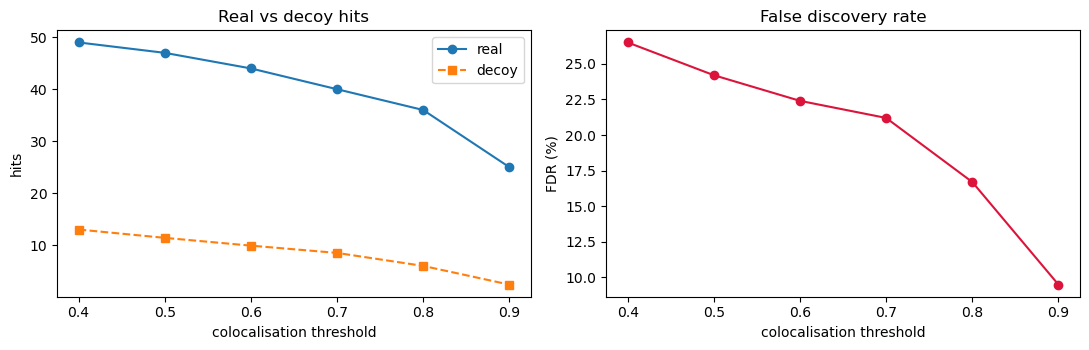

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ax[0].plot(sweep.coloc_min, sweep.n_real, "o-", label="real")
ax[0].plot(sweep.coloc_min, sweep.decoy_mean, "s--", label="decoy")
ax[0].set_xlabel("colocalisation threshold"); ax[0].set_ylabel("hits")
ax[0].legend(); ax[0].set_title("Real vs decoy hits")

ax[1].plot(sweep.coloc_min, sweep.fdr_percent, "o-", color="crimson")
ax[1].set_xlabel("colocalisation threshold"); ax[1].set_ylabel("FDR (%)")
ax[1].set_title("False discovery rate")

plt.tight_layout(); plt.show()

---
## 11. Inspect a result visually

Parent and proposed child should occupy the same region — that's what the
algorithm used to accept it.

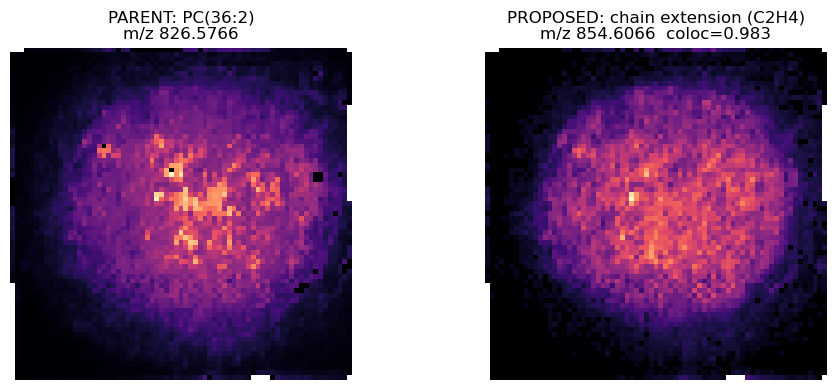

In [29]:
def ion_image(feature_index):
    img = np.full((H, W), np.nan)
    img[coords[:,1], coords[:,0]] = X[:, feature_index]
    return img

if len(prop):
    top = prop.iloc[0]
    parent_idx = int(np.argmin(np.abs(mzs - top.parent_mz)))
    child_idx  = int(top.feature_index)

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(ion_image(parent_idx), cmap="magma")
    ax[0].set_title(f"PARENT: {top.parent_name}\nm/z {top.parent_mz:.4f}")
    ax[0].axis("off")
    ax[1].imshow(ion_image(child_idx), cmap="magma")
    ax[1].set_title(f"PROPOSED: {top.transformation}\nm/z {top.mz_unknown:.4f}  coloc={top.coloc:.3f}")
    ax[1].axis("off")
    plt.tight_layout(); plt.show()
else:
    print("no propagated annotations to display")

---
## 12. Export

In [30]:
prop.to_csv("propagated_annotations.csv", index=False)
ann_real.to_csv("annotations_with_evidence.csv", index=False)
sweep.to_csv("fdr_threshold_sweep.csv", index=False)

print("saved 3 CSV files")

saved 3 CSV files


---
## Before you trust any of this

- Did the TIC image look like tissue?
- Is the annotated fraction plausible, or did the tolerance let everything match?
- Is enrichment over decoy well above 1? Below ~3 the signal is weak.
- Do the parent/child image pairs genuinely overlap?
- Are the proposed transformations chemically sensible for this tissue?

Propagated annotations are **Level 3** — hypotheses to confirm by MS/MS.